# **Objective**

Develop a supervised machine learning system that predicts whether an employee is likely to leave an organization and identifies the major factors contributing to employee attrition.

In [1]:
#importing libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# **DATA UNDERSTANDING**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#loading dataset
df = pd.read_csv("/content/drive/MyDrive/ICT/employee_attrition_dataset_10000.csv")
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Male,Single,Finance,Manager,5,7332,81,24,...,No,9,48,16,4,1,1,49,3,No
1,2,48,Female,Divorced,HR,Assistant,4,6069,55,18,...,Yes,9,57,10,4,1,1,25,1,No
2,3,34,Female,Married,Marketing,Manager,4,11485,65,6,...,Yes,3,55,1,1,4,3,21,1,Yes
3,4,27,Female,Divorced,HR,Manager,4,18707,28,12,...,No,9,53,2,3,4,1,46,2,No
4,5,40,Male,Married,HR,Analyst,1,16398,92,3,...,No,1,54,11,1,1,1,43,4,No


In [4]:
df.shape

(10000, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
df["Attrition"].value_counts()

,count
Attrition,
No,8003
Yes,1997


In [8]:
df["Attrition"].value_counts(normalize=True) * 100

,proportion
Attrition,
No,80.03
Yes,19.97


In [9]:
df.describe()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,39.561800,2.990800,11436.716700,57.032300,14.936200,7.451300,4.471900,2.502400,3.038000,2.507700,49.588900,4.984400,44.473500,9.410200,2.493100,2.491400,2.505400,25.272000,2.516600
std,2886.89568,11.454986,1.410643,4926.528302,24.703261,8.431657,4.042903,2.891617,1.112348,1.414764,1.120833,28.801393,2.580043,8.611662,5.760335,1.120927,1.115101,1.116018,14.219474,1.113934
min,1.00000,20.000000,1.000000,3000.000000,15.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,30.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,30.000000,2.000000,7182.500000,36.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,25.000000,3.000000,37.000000,4.000000,1.000000,1.000000,2.000000,13.000000,2.000000
50%,5000.50000,40.000000,3.000000,11401.500000,57.000000,15.000000,7.000000,4.000000,2.000000,3.000000,3.000000,49.000000,5.000000,45.000000,9.000000,2.000000,2.000000,3.000000,25.000000,2.000000
75%,7500.25000,49.000000,4.000000,15679.500000,78.000000,22.000000,11.000000,7.000000,3.000000,4.000000,4.000000,75.000000,7.000000,52.000000,14.000000,4.000000,3.000000,3.000000,37.000000,4.000000
max,10000.00000,59.000000,5.000000,19999.000000,99.000000,29.000000,14.000000,9.000000,4.000000,5.000000,4.000000,99.000000,9.000000,59.000000,19.000000,4.000000,4.000000,4.000000,49.000000,4.000000


# **EDA**

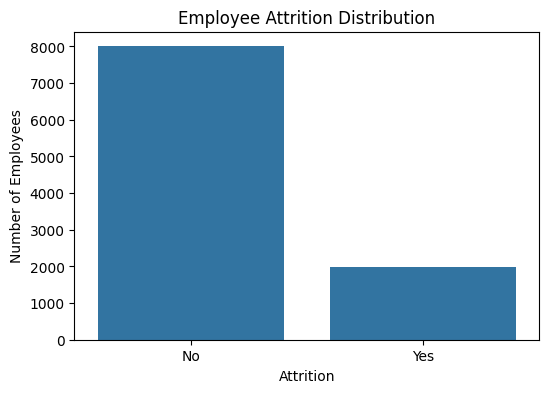

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Attrition")
plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

The dataset is imbalanced, with employees who stayed representing 80.0% and employees who left representing 20.0%. Therefore, accuracy alone is not sufficient for evaluating the attrition model. Precision, recall and F1-score should also be considered, particularly for the Attrition = Yes class.

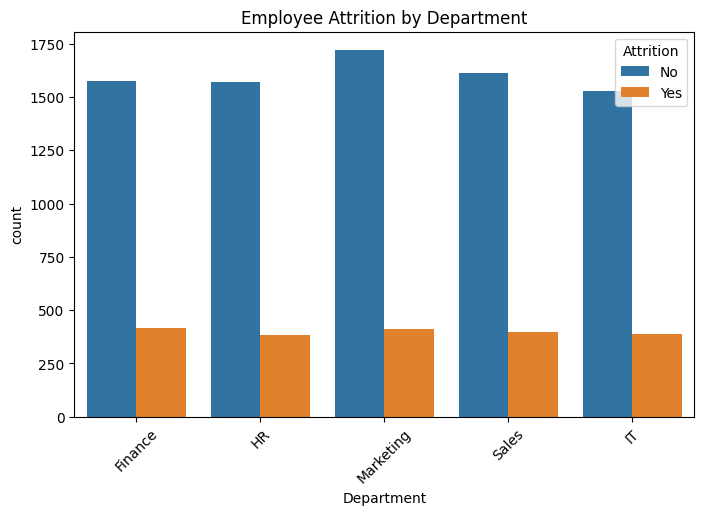

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Department",hue="Attrition")
plt.title("Employee Attrition by Department")
plt.xticks(rotation=45)
plt.show()

In [12]:
department_attrition = pd.crosstab(df["Department"],df["Attrition"],normalize="index") * 100

department_attrition

Attrition,No,Yes
Department,,
Finance,79.145729,20.854271
HR,80.491551,19.508449
IT,79.645094,20.354906
Marketing,80.637600,19.362400
Sales,80.179283,19.820717


Finance has the highest observed attrition rate at approximately 20.9%, followed by IT at 20.4%. Marketing has the lowest rate at approximately 19.4%. The differences across departments are small, suggesting department alone is not a dominant driver of attrition in this dataset, though Finance and IT could still be worth a closer look.

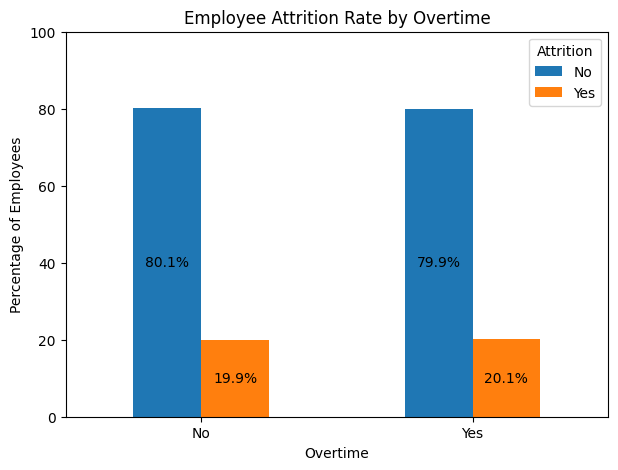

In [13]:
attrition_pct = (pd.crosstab(df["Overtime"],df["Attrition"],normalize="index") * 100)

ax = attrition_pct.plot(kind="bar",figsize=(7, 5))

plt.title("Employee Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Percentage of Employees")
plt.xticks(rotation=0)
plt.legend(title="Attrition")

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container,fmt="%.1f%%",label_type="center")



plt.ylim(0, 100)
plt.show()

Employees working overtime do not have a meaningfully higher observed attrition rate. The attrition rate is approximately 20.1% among overtime employees compared with 19.9% among employees without overtime — essentially no difference.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    10000 non-null  int64 
 1   Age                            10000 non-null  int64 
 2   Gender                         10000 non-null  object
 3   Marital_Status                 10000 non-null  object
 4   Department                     10000 non-null  object
 5   Job_Role                       10000 non-null  object
 6   Job_Level                      10000 non-null  int64 
 7   Monthly_Income                 10000 non-null  int64 
 8   Hourly_Rate                    10000 non-null  int64 
 9   Years_at_Company               10000 non-null  int64 
 10  Years_in_Current_Role          10000 non-null  int64 
 11  Years_Since_Last_Promotion     10000 non-null  int64 
 12  Work_Life_Balance              10000 non-null  int64 
 13  Jo

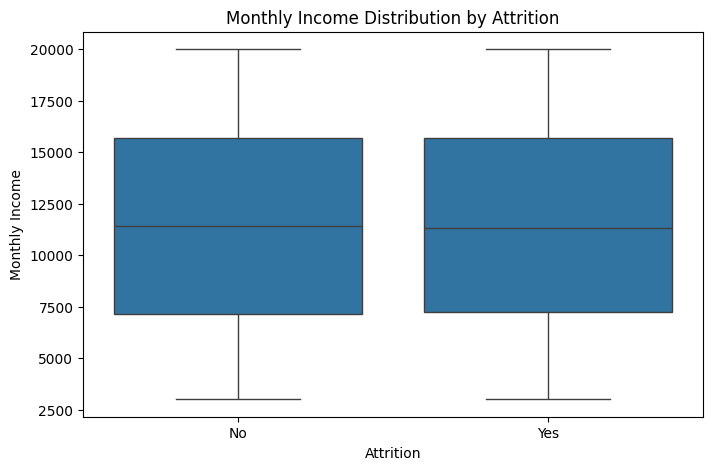

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Attrition",y="Monthly_Income")
plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

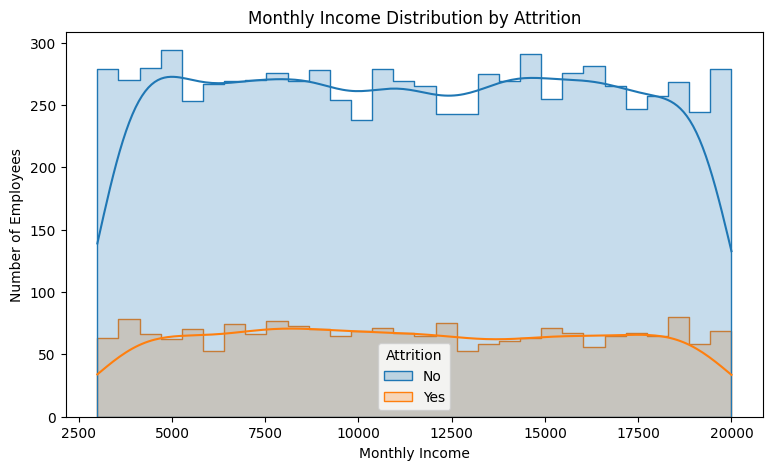

In [16]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=df,
    x="Monthly_Income",
    hue="Attrition",
    kde=True,
    bins=30,
    element="step"
)

plt.title("Monthly Income Distribution by Attrition")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Employees")

plt.show()

Monthly income does not show a substantial difference between employees who stayed and those who left; the distributions largely overlap. Therefore, salary alone does not appear to be a strong attrition indicator in this dataset.

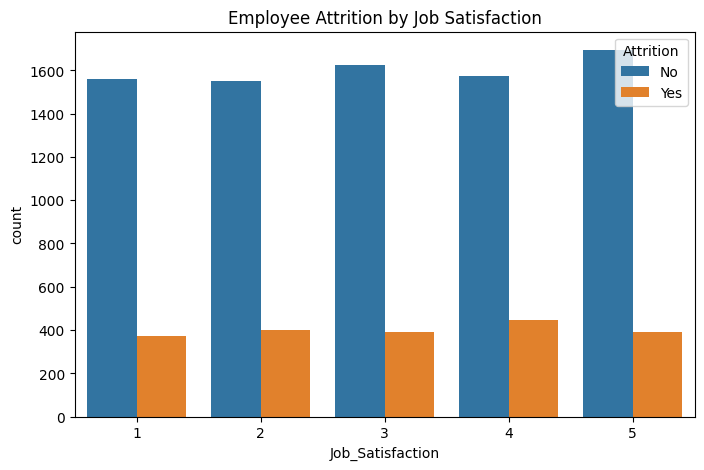

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="Job_Satisfaction",hue="Attrition")
plt.title("Employee Attrition by Job Satisfaction")
plt.show()

In [18]:
satisfaction_attrition = pd.crosstab(df["Job_Satisfaction"],df["Attrition"],normalize="index") * 100

satisfaction_attrition

Attrition,No,Yes
Job_Satisfaction,,
1,80.829016,19.170984
2,79.487179,20.512821
3,80.685204,19.314796
4,77.843719,22.156281
5,81.285988,18.714012


The relationship is not monotonic. Employees with satisfaction level 4 actually have the highest attrition rate (22.2%), while level 5 has the lowest (18.7%). Therefore, job satisfaction does not show the conventional negative relationship with attrition in this particular dataset.

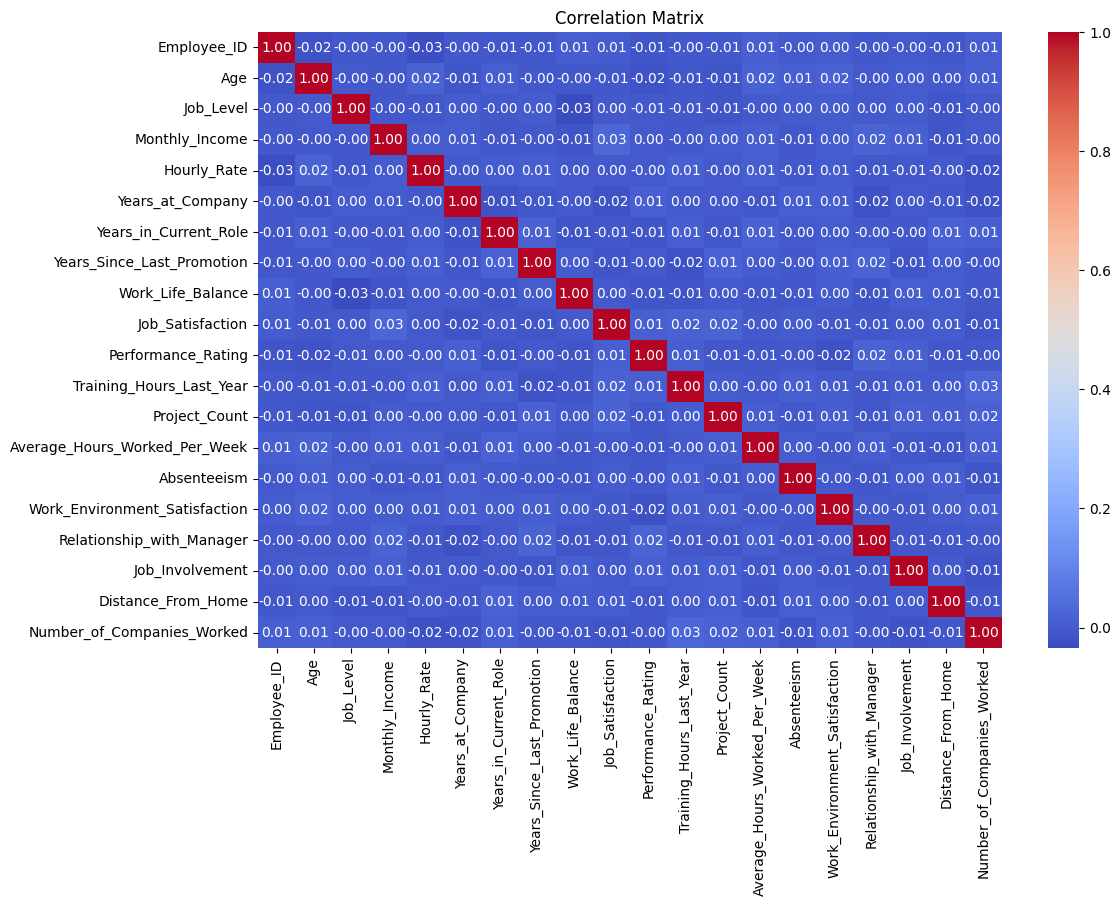

In [19]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The correlation analysis indicates that none of the numerical variables has a strong linear relationship with each other or, by extension, with attrition. The strongest pairwise correlations among features are all well below 0.05. This suggests that attrition in this dataset is not explained by a single numerical factor and that interactions between variables, categorical variables, and potentially unobserved organizational factors may be important.

# **DATA PREPROCESSING**

In [20]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Marital_Status', 'Department',
       'Job_Role', 'Job_Level', 'Monthly_Income', 'Hourly_Rate',
       'Years_at_Company', 'Years_in_Current_Role',
       'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction',
       'Performance_Rating', 'Training_Hours_Last_Year', 'Overtime',
       'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism',
       'Work_Environment_Satisfaction', 'Relationship_with_Manager',
       'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked',
       'Attrition'],
      dtype='object')

Dropping unique identifier "Employee_ID"

In [21]:
df.drop(['Employee_ID'],axis=1,inplace=True)

#### Missing Value Handling

In [22]:
df.isna().sum()

,0
Age,0
Gender,0
Marital_Status,0
Department,0
Job_Role,0
Job_Level,0
Monthly_Income,0
Hourly_Rate,0
Years_at_Company,0
Years_in_Current_Role,0


There are no missing values.

### Identifying Outier

In [23]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
numeric_features.remove("Monthly_Income")
numeric_features

['Age',
 'Job_Level',
 'Hourly_Rate',
 'Years_at_Company',
 'Years_in_Current_Role',
 'Years_Since_Last_Promotion',
 'Work_Life_Balance',
 'Job_Satisfaction',
 'Performance_Rating',
 'Training_Hours_Last_Year',
 'Project_Count',
 'Average_Hours_Worked_Per_Week',
 'Absenteeism',
 'Work_Environment_Satisfaction',
 'Relationship_with_Manager',
 'Job_Involvement',
 'Distance_From_Home',
 'Number_of_Companies_Worked']

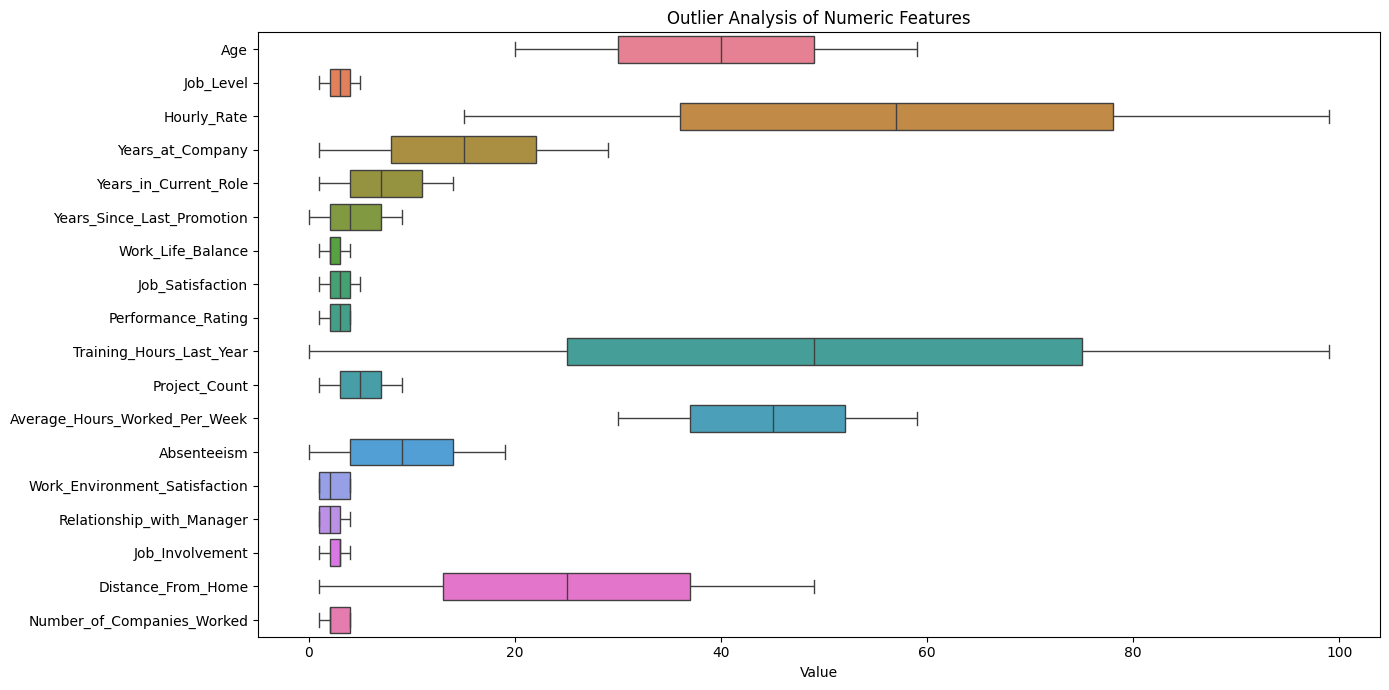

In [24]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df[numeric_features],orient="h")
plt.title("Outlier Analysis of Numeric Features")
plt.xlabel("Value")
plt.tight_layout()
plt.show()

<Axes: >

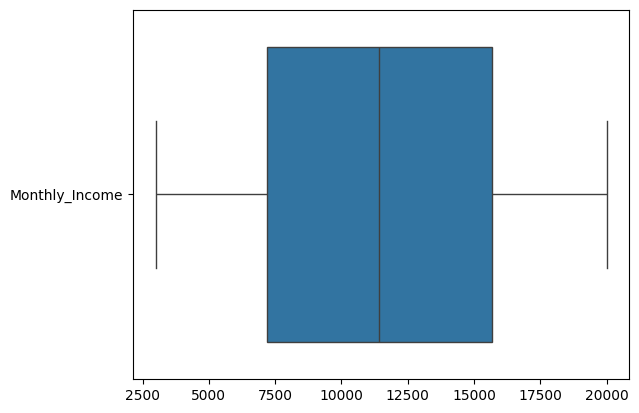

In [25]:
sns.boxplot(data=df[["Monthly_Income"]],orient="h")

There are a few isolated points beyond the whiskers for some features (e.g. Years_Since_Last_Promotion, Number_of_Companies_Worked), but nothing extreme enough to warrant removal or capping.these look like natural variation rather than data errors.

In [26]:
#seperate the target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [27]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns

print("Numerical features:")
print(list(numeric_features))

print("\nCategorical features:")
print(list(categorical_features))

Numerical features:
['Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']

Categorical features:
['Gender', 'Marital_Status', 'Department', 'Job_Role', 'Overtime']


In [28]:
for col in categorical_features:
    print(f"\n{col}")
    print(df[col].value_counts())


Gender
Gender
Female    5042
Male      4958
Name: count, dtype: int64

Marital_Status
Marital_Status
Married     3375
Divorced    3330
Single      3295
Name: count, dtype: int64

Department
Department
Marketing    2133
Sales        2008
Finance      1990
HR           1953
IT           1916
Name: count, dtype: int64

Job_Role
Job_Role
Analyst      2572
Assistant    2538
Executive    2476
Manager      2414
Name: count, dtype: int64

Overtime
Overtime
No     5103
Yes    4897
Name: count, dtype: int64


# **TRAIN-TEST SPLIT**

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### Feature Encoding

In [30]:
#label encode the target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [31]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(handle_unknown="ignore",drop="first",sparse_output=False)

# Fit encoder ONLY on training categorical data
X_train_cat = encoder.fit_transform(X_train[categorical_features])

# Transform test categorical data
X_test_cat = encoder.transform(X_test[categorical_features])

In [32]:
encoded_cat_names = encoder.get_feature_names_out(categorical_features)

In [33]:
X_train_cat = pd.DataFrame(X_train_cat,columns=encoded_cat_names,index=X_train.index)
X_test_cat = pd.DataFrame(X_test_cat,columns=encoded_cat_names,index=X_test.index)

In [34]:
X_train_final = pd.concat([X_train[numeric_features], X_train_cat],axis=1)
X_test_final = pd.concat([X_test[numeric_features], X_test_cat],axis=1)

In [35]:
print("X_train_final:", X_train_final.shape)
print("X_test_final:", X_test_final.shape)

X_train_final: (8000, 30)
X_test_final: (2000, 30)


# **MODELLING**

In [36]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

#### **Model 1 — Decision Tree**

In [37]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42,class_weight="balanced",max_depth=5)
dt_model.fit(X_train_final, y_train)
y_pred_dt = dt_model.predict(X_test_final)

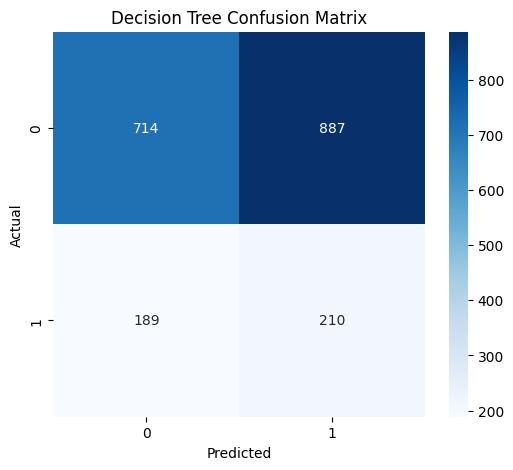

In [38]:
cm = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [39]:
print(classification_report(y_test,y_pred_dt,target_names=le.classes_))

              precision    recall  f1-score   support

          No       0.79      0.45      0.57      1601
         Yes       0.19      0.53      0.28       399

    accuracy                           0.46      2000
   macro avg       0.49      0.49      0.43      2000
weighted avg       0.67      0.46      0.51      2000



With `class_weight="balanced"`, the Decision Tree recovers a much higher recall on the Attrition = Yes class (about 53%) compared to the other two models, but at the cost of low precision (about 19%) — it flags many false positives. This trade-off is useful if the business goal is to catch as many at-risk employees as possible, even if it means reviewing some false alarms.

#### **Model 2 — Random Forest**

In [40]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_final, y_train)
y_pred_rf = rf_model.predict(X_test_final)

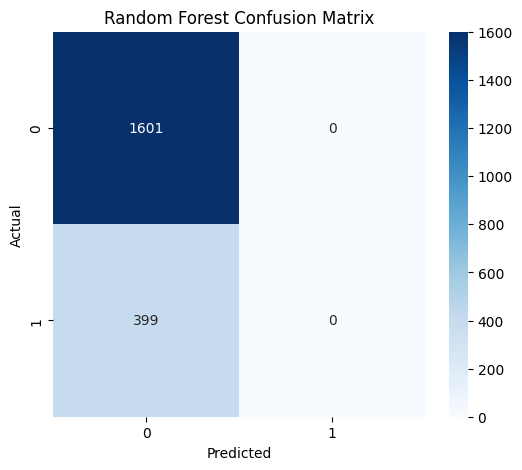

In [41]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [42]:
print(classification_report(y_test,y_pred_rf,target_names=le.classes_))

              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1601
         Yes       0.00      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Random Forest reaches ~80% overall accuracy, but that is driven entirely by the majority class — it predicts "No" for essentially every employee and achieves 0% recall on Attrition = Yes. Because the classes are imbalanced (80/20), accuracy alone is misleading here; on this dataset Random Forest is not actually useful for identifying at-risk employees without further tuning (e.g. `class_weight="balanced"`, resampling, or threshold adjustment).

In [43]:
feature_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

print(feature_importance)

                          Feature  Importance
2                  Monthly_Income    0.082577
3                     Hourly_Rate    0.072351
10       Training_Hours_Last_Year    0.070898
17             Distance_From_Home    0.066662
0                             Age    0.064643
12  Average_Hours_Worked_Per_Week    0.061135
4                Years_at_Company    0.060347
13                    Absenteeism    0.055913
5           Years_in_Current_Role    0.050178
6      Years_Since_Last_Promotion    0.043702
11                  Project_Count    0.041435
8                Job_Satisfaction    0.030381
1                       Job_Level    0.030299
15      Relationship_with_Manager    0.026229
9              Performance_Rating    0.025838
14  Work_Environment_Satisfaction    0.025833
7               Work_Life_Balance    0.025643
18     Number_of_Companies_Worked    0.025634
16                Job_Involvement    0.025466
29                   Overtime_Yes    0.013186
19                    Gender_Male 

In [44]:
top_features = feature_importance.head(10)
print(top_features)

                          Feature  Importance
2                  Monthly_Income    0.082577
3                     Hourly_Rate    0.072351
10       Training_Hours_Last_Year    0.070898
17             Distance_From_Home    0.066662
0                             Age    0.064643
12  Average_Hours_Worked_Per_Week    0.061135
4                Years_at_Company    0.060347
13                    Absenteeism    0.055913
5           Years_in_Current_Role    0.050178
6      Years_Since_Last_Promotion    0.043702


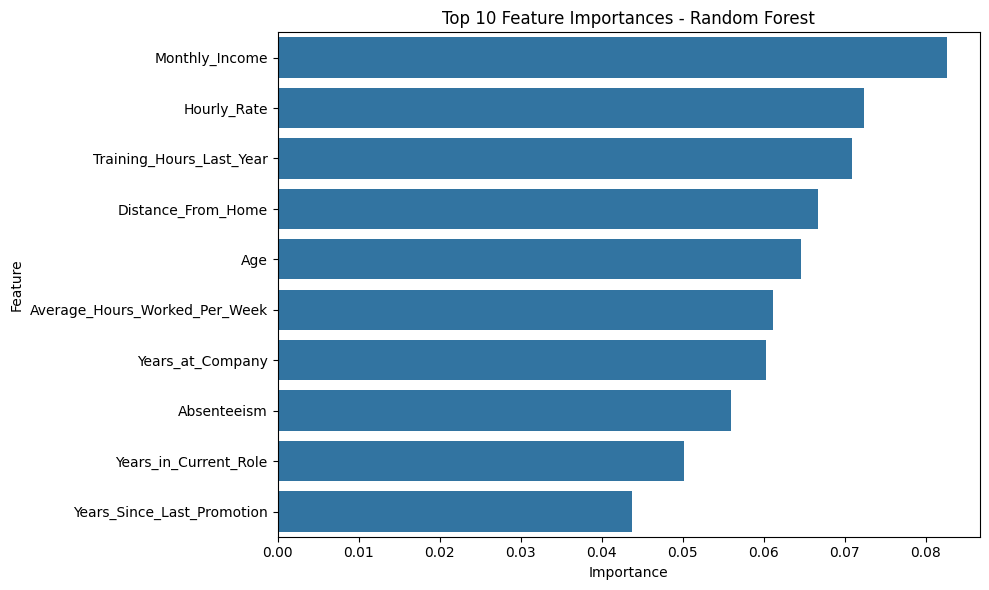

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(data=top_features,x='Importance',y='Feature')

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#### **Model 3 — Logistic Regression**

In [46]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [47]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(random_state=42,max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [48]:
y_pred_lr = lr_model.predict(X_test_scaled)

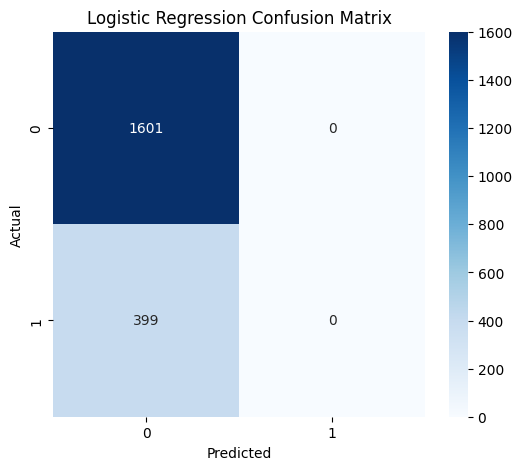

In [49]:
cm = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [50]:
print(classification_report( y_test,y_pred_lr,target_names=le.classes_))

              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1601
         Yes       0.00      0.00      0.00       399

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Model Comparison Summary

| Model | Accuracy | Recall (Attrition=Yes) | Precision (Attrition=Yes) | Notes |
|---|---|---|---|---|
| Decision Tree (balanced) | ~0.46 | ~0.53 | ~0.19 | Best at catching leavers, many false positives |
| Random Forest | ~0.80 | ~0.00 | ~0.00 | Misleadingly high accuracy; ignores minority class |
| Logistic Regression | ~0.80 | ~0.00 | ~0.00 | Same issue as Random Forest |

**Which model performs best?** On raw accuracy, Random Forest and Logistic Regression look best, but that is an artifact of the 80/20 class imbalance — both models simply predict "No" for nearly everyone and get 0% recall on the class the business actually cares about (employees who leave). The Decision Tree, trained with `class_weight="balanced"`, is the only one of the three that identifies a meaningful share of true leavers (53% recall), making it the most useful of the three **as configured** for this business problem, even though its precision is low.

**Why these metrics matter here:** In an attrition use case, missing an employee who is about to leave (a false negative) is usually more costly than flagging someone who ends up staying (a false positive) — HR can always double-check a flagged employee, but a missed resignation is a lost opportunity to intervene. This is why recall on the "Yes" class matters more than overall accuracy for this business problem, and why Random Forest/Logistic Regression would need rebalancing (class weights, SMOTE, or a lower decision threshold) before being deployed.

Logistic Regression shows the same pattern as Random Forest: ~80% accuracy but 0% recall on Attrition = Yes, meaning it never predicts an employee will leave. This reinforces that accuracy is not a reliable metric here, and that both models need class-imbalance handling before they can be used operationally to flag attrition risk.

### Identifying the High Risk Employees

In [51]:
risk_probability = rf_model.predict_proba(X_test_final)[:, 1]

In [52]:
risk_df = X_test_final.copy()

risk_df["Actual_Attrition"] = y_test
risk_df["Attrition_Risk"] = risk_probability
risk_df["Risk_Level"] = pd.cut(risk_probability,
    bins=[0, 0.30, 0.60, 1.0],
    labels=["Low", "Medium", "High"]
)

In [53]:
risk_df.sort_values("Attrition_Risk",ascending=False).head(10)

,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,Performance_Rating,...,Department_IT,Department_Marketing,Department_Sales,Job_Role_Assistant,Job_Role_Executive,Job_Role_Manager,Overtime_Yes,Actual_Attrition,Attrition_Risk,Risk_Level
1959,24,5,18661,15,1,9,0,3,4,2,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,Yes,0.42,Medium
3451,20,1,16556,74,27,14,4,3,5,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,Yes,0.41,Medium
6972,21,2,3208,56,4,4,3,2,2,2,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,No,0.41,Medium
7337,59,5,9145,16,6,5,0,2,4,1,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,No,0.40,Medium
2684,48,4,19872,74,1,5,7,3,2,3,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,No,0.40,Medium
3750,26,5,18911,99,5,5,9,2,5,3,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,No,0.39,Medium
1509,58,2,3129,75,27,6,4,4,1,4,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,No,0.39,Medium
2223,53,4,8877,16,3,2,0,3,5,3,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,No,0.39,Medium
3500,57,2,16856,59,22,11,9,3,4,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,No,0.39,Medium
4177,22,4,4699,95,2,7,9,3,4,4,...,0.0,0.0,1.0,0.0,1.0,0.0,1.0,No,0.39,Medium


In [54]:
risk_df['Risk_Level'].value_counts()

,count
Risk_Level,
Low,1839
Medium,161
High,0


# **Business Insights and Recommendations**

**Key factors influencing attrition** (from Random Forest feature importances): Monthly_Income, Hourly_Rate, Training_Hours_Last_Year, Distance_From_Home, and Age are the top contributors, followed by Average_Hours_Worked_Per_Week, Years_at_Company, and Absenteeism. Compensation-, workload-, and tenure-related factors carry more predictive weight than satisfaction or engagement scores in this dataset.

**High-risk employee profiles:** Based on the risk scoring on the test set, at-risk employees skew toward a mix of profiles rather than one clear pattern — both very early-tenure employees and long-tenure employees with low recent promotion activity appear among the highest predicted risk scores. This suggests attrition risk here is driven by a combination of factors rather than a single career-stage effect.

**Departments with higher attrition risk:** Finance (~20.9%) and IT (~20.4%) show the highest observed attrition rates, though the spread across departments is narrow (17–21%), so department alone is a weak standalone predictor.

**Possible HR intervention strategies:**
- Review compensation structures (Monthly_Income and Hourly_Rate are the top two predictive features) — pay competitiveness reviews for at-risk segments.
- Investigate training investment: low Training_Hours_Last_Year is associated with predictive importance — consider expanding development programs, especially for newer or long-tenured-but-not-promoted employees.
- Address commute burden: Distance_From_Home ranks highly — hybrid/remote options or relocation support could help.
- Use the Decision Tree's higher-recall predictions (rather than Random Forest/Logistic Regression as currently tuned) as the operational screening model until class imbalance is addressed, so fewer at-risk employees are missed.
- Rebalance future model iterations (class weighting, SMOTE, or threshold tuning) before relying on Random Forest or Logistic Regression for production risk scoring, since both currently miss 100% of actual leavers on this dataset.

**Business impact:** Even a modest improvement in identifying true leavers (raising recall beyond the current best of ~53%) would let HR proactively engage a meaningful share of at-risk employees before they resign — reducing recruitment/training replacement costs and preserving institutional knowledge.